# Create and analyze trends across the summer stats

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from cartopy import crs as ccrs, feature as cfeature
import netCDF4
from netCDF4 import Dataset
from datetime import datetime as dt

## Load LSM for filtering

In [26]:
file_path = '../../../Data/ERA5-global/ERA5-2023-09-01-CoordFixed-LSM.nc'
ds_lsm = xr.open_dataset(file_path)
ds_lsm

<xarray.Dataset> Size: 8MB
Dimensions:  (lat: 721, lon: 1440)
Coordinates:
  * lat      (lat) float32 3kB 90.0 89.75 89.5 89.25 ... -89.5 -89.75 -90.0
  * lon      (lon) float32 6kB -180.0 -179.8 -179.5 -179.2 ... 179.2 179.5 179.8
Data variables:
    lsm      (lat, lon) float64 8MB ...

## load data from analysis period 1990-2022 (can expand to 2023 when we have more 2024 data)

In [33]:
%%time
# start with one year and lsm and add a coordinate for the year
year = 1990
input_path = '../../../Data/ERA5-global/Analysis/New/'+str(year)+'_summer_stats.nc'
ds = xr.open_dataset(input_path)
ds = ds.merge(ds_lsm)
ds = ds.expand_dims("time").assign_coords(time=("time", [dt(year,1,1)]))

# loop thru remaining years and also add time coord
input_years = np.arange(1991,2023,1)

for year in input_years:
    input_path = '../../../Data/ERA5-global/Analysis/New/'+str(year)+'_summer_stats.nc'
    ds_i = xr.open_dataset(input_path)
    ds_i = ds_i.merge(ds_lsm)
    ds_i = ds_i.expand_dims("time").assign_coords(time=("time", [dt(year,1,1)]))
    ds = ds.merge(ds_i)

ds

<xarray.Dataset> Size: 2GB
Dimensions:       (lat: 721, lon: 1440, time: 33)
Coordinates:
  * lat           (lat) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * lon           (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
  * time          (time) datetime64[ns] 264B 1990-01-01 ... 2022-01-01
Data variables:
    SummerStart   (time, lat, lon) float64 274MB 146.0 146.0 ... 212.0 212.0
    SummerEnd     (time, lat, lon) float64 274MB 220.0 220.0 ... 242.0 242.0
    SummerTmax    (time, lat, lon) float64 274MB 174.0 174.0 ... 213.0 213.0
    SummerHeat    (time, lat, lon) float64 274MB 1.84e+04 1.84e+04 ... 8.191e+03
    SummerLength  (time, lat, lon) float64 274MB 75.0 75.0 75.0 ... 31.0 31.0
    SummerRMSE    (time, lat, lon) float64 274MB 7.937 7.937 ... 4.992 4.992
    SummerR2      (time, lat, lon) float64 274MB 0.5064 0.5064 ... 0.7734 0.7734
    lsm           (time, lat, lon) float64 274MB 1.0 1.0 1.0 1.0 ... 0.0 0.0 0.0

# Plots

### Global unweighted and weighted by cos(lat) summer length

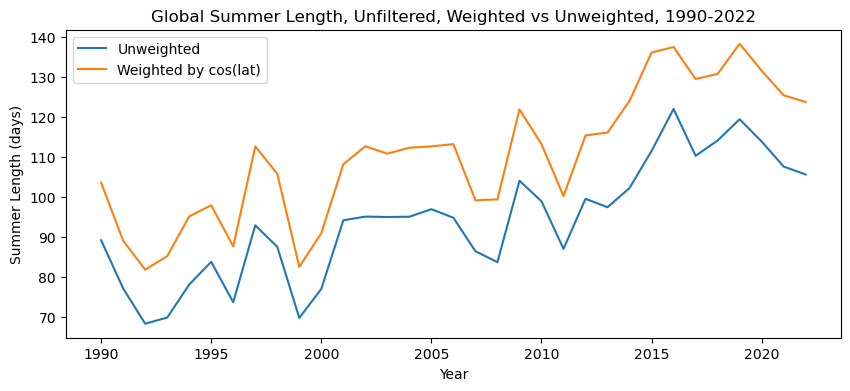

In [40]:
avg_glob_summ_length = ds.SummerLength.mean(dim=['lat','lon'])

# find weights (this is a regular grid so we can use cos(latitude))
weights = np.cos(np.deg2rad(ds.lat))
weights.name = "weights"
# take the weighted spatial mean since the latitude range of the region of interest is large
wavg_glob_summ_length = ds.SummerLength.weighted(weights).mean(dim=['lat','lon'])


plt.figure(figsize=(10,4))
plt.plot(avg_glob_summ_length.time.dt.year, avg_glob_summ_length, label="Unweighted")
plt.plot(wavg_glob_summ_length.time.dt.year, wavg_glob_summ_length, label="Weighted by cos(lat)")
plt.xlabel("Year")
plt.ylabel("Summer Length (days)")
plt.title("Global Summer Length, Unfiltered, Weighted vs Unweighted, 1990-2022")
plt.legend()
plt.show()

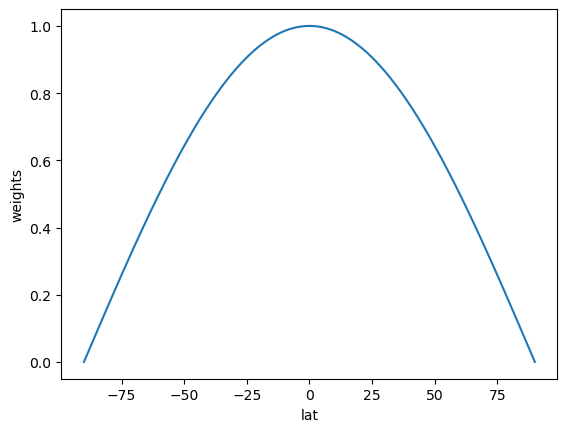

In [154]:
weights.plot()

### All remaining plots are weighted 

### Global Land vs Ocean Summer Length

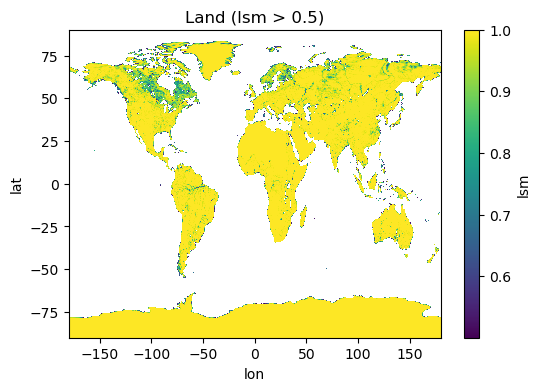

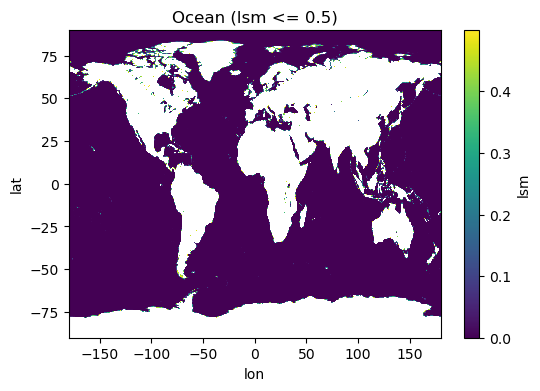

In [108]:
# can be land and inland small water
ds_land = ds.where(ds.lsm > 0.5)
ds_ocean = ds.where(ds.lsm <= 0.5)

plt.figure(figsize=(6,4))
#plt.subplot(111)
ds_land.lsm.sel(time='2020').plot()
plt.title("Land (lsm > 0.5)")
#plt.subplot(122)
plt.figure(figsize=(6,4))
ds_ocean.lsm.sel(time='2020').plot()
plt.title("Ocean (lsm <= 0.5)")
#plt.tight_layout()
plt.show()

In [106]:
#ds_land

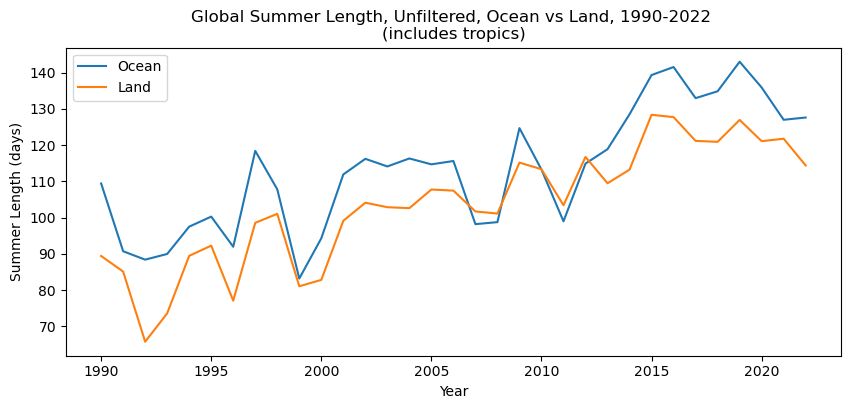

In [110]:


# take the weighted spatial mean since the latitude range of the region of interest is large
wavg_land_sl = ds_land.SummerLength.weighted(weights).mean(dim=['lat','lon'])
wavg_ocean_sl = ds_ocean.SummerLength.weighted(weights).mean(dim=['lat','lon'])

plt.figure(figsize=(10,4))
plt.plot(wavg_ocean_sl.time.dt.year, wavg_ocean_sl, label="Ocean")
plt.plot(wavg_land_sl.time.dt.year, wavg_land_sl, label="Land")

plt.xlabel("Year")
plt.ylabel("Summer Length (days)")
plt.title("Global Summer Length, Unfiltered, Ocean vs Land, 1990-2022 \n(includes tropics)")
plt.legend()
plt.show()

## Global Mid-latitude Land vs Ocean

<>:12: SyntaxWarning: invalid escape sequence '\c'
<>:12: SyntaxWarning: invalid escape sequence '\c'
/var/folders/x9/4cv754f12hv2bf6s__9xrzj80000gp/T/ipykernel_88424/3261479347.py:12: SyntaxWarning: invalid escape sequence '\c'
  plt.title("Global Midlatitude Summer Length, Unfiltered, Ocean vs Land, 1990-2022 \n[23.5, 70]$^\circ$N and [-70, -23]$^\circ$S")


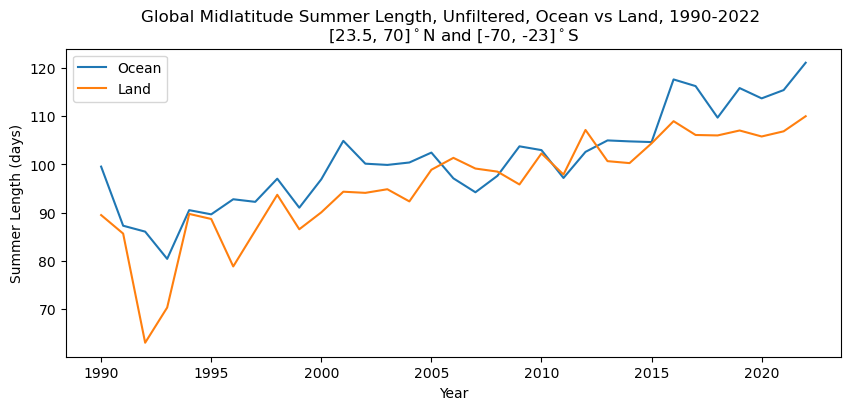

In [54]:
# take the weighted spatial mean since the latitude range of the region of interest is large
wavg_midlat_land_sl = ds_land.SummerLength.where(((ds_land.lat >= 23.5) & (ds_land.lat <= 70)) | 
                                         ((ds_land.lat <= -23.5) & (ds_land.lat >= -70))).weighted(weights).mean(dim=['lat','lon'])
wavg_midlat_ocean_sl = ds_ocean.SummerLength.where(((ds_ocean.lat >= 23.5) & (ds_ocean.lat <= 70)) |
                                           ((ds_ocean.lat <= -23.5) & (ds_ocean.lat >= -70))).weighted(weights).mean(dim=['lat','lon'])

plt.figure(figsize=(10,4))
plt.plot(wavg_midlat_ocean_sl.time.dt.year, wavg_midlat_ocean_sl, label="Ocean")
plt.plot(wavg_midlat_land_sl.time.dt.year, wavg_midlat_land_sl, label="Land")
plt.xlabel("Year")
plt.ylabel("Summer Length (days)")
plt.title("Global Midlatitude Summer Length, Unfiltered, Ocean vs Land, 1990-2022 \n[23.5, 70]$^\circ$N and [-70, -23]$^\circ$S")
plt.legend()
plt.show()

## NH vs SH Mid-latitude Land

<>:46: SyntaxWarning: invalid escape sequence '\p'
<>:50: SyntaxWarning: invalid escape sequence '\p'
<>:54: SyntaxWarning: invalid escape sequence '\c'
<>:46: SyntaxWarning: invalid escape sequence '\p'
<>:50: SyntaxWarning: invalid escape sequence '\p'
<>:54: SyntaxWarning: invalid escape sequence '\c'
/var/folders/x9/4cv754f12hv2bf6s__9xrzj80000gp/T/ipykernel_88424/3165437762.py:46: SyntaxWarning: invalid escape sequence '\p'
  label="Slope = "+str(slope_nh)+" $\pm$ "+str(slope_nh_sd)+" (days/yr), $R^2$ = "+str(r_squared_nh))
/var/folders/x9/4cv754f12hv2bf6s__9xrzj80000gp/T/ipykernel_88424/3165437762.py:50: SyntaxWarning: invalid escape sequence '\p'
  label="Slope = "+str(slope_sh)+" $\pm$ "+str(slope_nh_sd)+" (days/yr), $R^2$ = "+str(r_squared_sh))
/var/folders/x9/4cv754f12hv2bf6s__9xrzj80000gp/T/ipykernel_88424/3165437762.py:54: SyntaxWarning: invalid escape sequence '\c'
  plt.title("Midlatitude Land Summer Length, Unfiltered, NH vs SH, 1990-2022 \n[23.5, 70]$^\circ$N or [-70, -

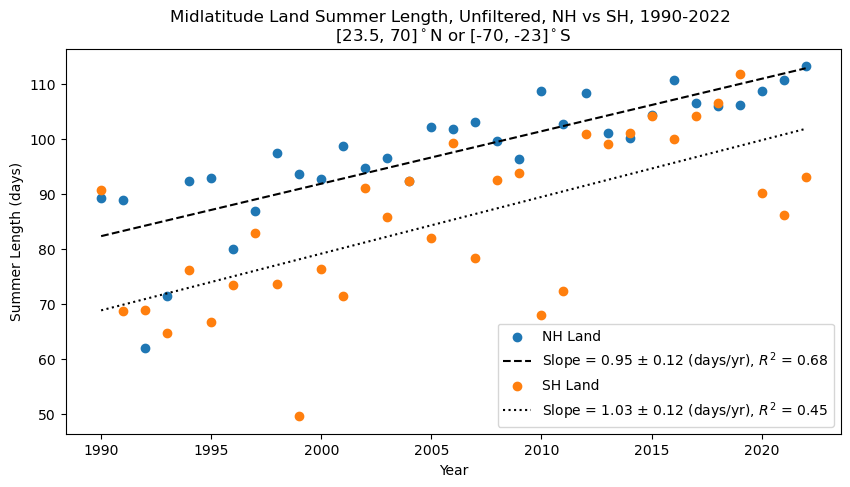

In [140]:
# take the weighted spatial mean since the latitude range of the region of interest is large

# NH
wavg_nh_land_sl = ds_land.SummerLength.where(((ds_land.lat >= 23.5) & (ds_land.lat <= 70))).weighted(weights).mean(dim=['lat','lon'])
x_nh = wavg_nh_land_sl.time.dt.year.values
y_nh = wavg_nh_land_sl.values

# linear fit
# error on slope via https://stackoverflow.com/questions/27634270/how-to-find-error-on-slope-and-intercept-using-numpy-polyfit
# error is stddev of 
coefs_nh, V = np.polyfit(x_nh, y_nh, 1, cov=True)
poly_nh = np.poly1d(coefs_nh)
slope_nh = np.round(coefs_nh[0],2)
slope_nh_sd = np.round(np.sqrt(V[0][0]),2)


# add in R^2 and RMSE
ymean = np.mean(y_nh)
ss_total = np.sum((y_nh - ymean)**2)
ss_res = np.sum((y_nh - poly_nh(x_nh))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_nh = np.round(1 - (ss_res / ss_total),2)

# SH
wavg_sh_land_sl = ds_land.SummerLength.where(((ds_land.lat <= -23.5) & (ds_land.lat >= -70))).weighted(weights).mean(dim=['lat','lon'])
x_sh = wavg_sh_land_sl.time.dt.year.values
y_sh = wavg_sh_land_sl.values

# linear fit
coefs_sh, V = np.polyfit(x_sh, y_sh, 1, cov=True)
poly_sh = np.poly1d(coefs_sh)
slope_sh = np.round(coefs_sh[0],2)
slope_sh_sd = np.round(np.sqrt(V[0][0]),2)

# add in R^2 and RMSE
ymean = np.mean(y_sh)
ss_total = np.sum((y_sh - ymean)**2)
ss_res = np.sum((y_sh - poly_sh(x_sh))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_sh = np.round(1 - (ss_res / ss_total),2)


plt.figure(figsize=(10,5))
plt.scatter(wavg_nh_land_sl.time.dt.year, wavg_nh_land_sl, label="NH Land")
plt.plot(x_nh, poly_nh(x_nh), linestyle="dashed", color='k', 
         label="Slope = "+str(slope_nh)+" $\pm$ "+str(slope_nh_sd)+" (days/yr), $R^2$ = "+str(r_squared_nh))

plt.scatter(wavg_sh_land_sl.time.dt.year, wavg_sh_land_sl, label="SH Land")
plt.plot(x_sh, poly_sh(x_sh), linestyle="dotted", color='k',
         label="Slope = "+str(slope_sh)+" $\pm$ "+str(slope_nh_sd)+" (days/yr), $R^2$ = "+str(r_squared_sh))

plt.xlabel("Year")
plt.ylabel("Summer Length (days)")
plt.title("Midlatitude Land Summer Length, Unfiltered, NH vs SH, 1990-2022 \n[23.5, 70]$^\circ$N or [-70, -23]$^\circ$S")
plt.legend()
plt.show()

## NH vs SH Mid-latitude Ocean

<>:44: SyntaxWarning: invalid escape sequence '\p'
<>:48: SyntaxWarning: invalid escape sequence '\p'
<>:52: SyntaxWarning: invalid escape sequence '\c'
<>:44: SyntaxWarning: invalid escape sequence '\p'
<>:48: SyntaxWarning: invalid escape sequence '\p'
<>:52: SyntaxWarning: invalid escape sequence '\c'
/var/folders/x9/4cv754f12hv2bf6s__9xrzj80000gp/T/ipykernel_88424/1336913500.py:44: SyntaxWarning: invalid escape sequence '\p'
  label="Slope = "+str(slope_o_nh)+" $\pm$ "+str(slope_o_nh_sd)+" (days/yr), $R^2$ = "+str(r_squared_o_nh))
/var/folders/x9/4cv754f12hv2bf6s__9xrzj80000gp/T/ipykernel_88424/1336913500.py:48: SyntaxWarning: invalid escape sequence '\p'
  label="Slope = "+str(slope_o_sh)+" $\pm$ "+str(slope_o_nh_sd)+" (days/yr), $R^2$ = "+str(r_squared_o_sh))
/var/folders/x9/4cv754f12hv2bf6s__9xrzj80000gp/T/ipykernel_88424/1336913500.py:52: SyntaxWarning: invalid escape sequence '\c'
  plt.title("Midlatitude Ocean Summer Length, Unfiltered, NH vs SH, 1990-2022 \n[23.5, 70]$^\circ

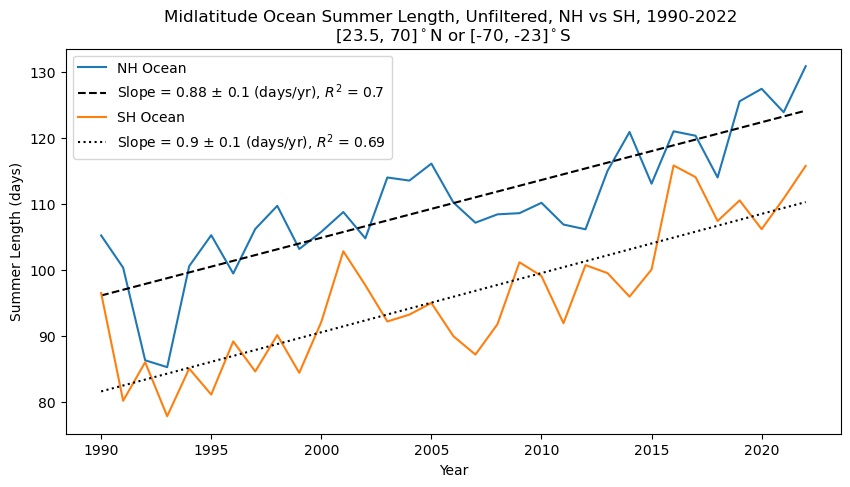

In [141]:
# NH
# get linear fits to the data and plot as well
wavg_nh_ocean_sl = ds_ocean.SummerLength.where(((ds_ocean.lat >= 23.5) & (ds_ocean.lat <= 70))).weighted(weights).mean(dim=['lat','lon'])
x_nh = wavg_nh_ocean_sl.time.dt.year.values
y_nh = wavg_nh_ocean_sl.values

# linear fit
# error on slope via https://stackoverflow.com/questions/27634270/how-to-find-error-on-slope-and-intercept-using-numpy-polyfit
# error is stddev of 
coefs_nh, V = np.polyfit(x_nh, y_nh, 1, cov=True)
poly_o_nh = np.poly1d(coefs_nh)
slope_o_nh = np.round(coefs_nh[0],2)
slope_o_nh_sd = np.round(np.sqrt(V[0][0]),2)

# add in R^2 and RMSE
ymean = np.mean(y_nh)
ss_total = np.sum((y_nh - ymean)**2)
ss_res = np.sum((y_nh - poly_o_nh(x_nh))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_o_nh = np.round(1 - (ss_res / ss_total),2)

# SH
wavg_sh_ocean_sl = ds_ocean.SummerLength.where(((ds_ocean.lat <= -23.5) & (ds_ocean.lat >= -70))).weighted(weights).mean(dim=['lat','lon'])
x_sh = wavg_sh_ocean_sl.time.dt.year.values
y_sh = wavg_sh_ocean_sl.values

# linear fit
coefs_sh, V = np.polyfit(x_sh, y_sh, 1, cov=True)
poly_o_sh = np.poly1d(coefs_sh)
slope_o_sh = np.round(coefs_sh[0],2)
slope_o_sh_sd = np.round(np.sqrt(V[0][0]),2)

# add in R^2 and RMSE
ymean = np.mean(y_sh)
ss_total = np.sum((y_sh - ymean)**2)
ss_res = np.sum((y_sh - poly_o_sh(x_sh))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_o_sh = np.round(1 - (ss_res / ss_total),2)


plt.figure(figsize=(10,5))
plt.plot(wavg_nh_ocean_sl.time.dt.year, wavg_nh_ocean_sl, label="NH Ocean")
plt.plot(x_nh, poly_o_nh(x_nh), linestyle="dashed", color='k', 
         label="Slope = "+str(slope_o_nh)+" $\pm$ "+str(slope_o_nh_sd)+" (days/yr), $R^2$ = "+str(r_squared_o_nh))

plt.plot(wavg_sh_ocean_sl.time.dt.year, wavg_sh_ocean_sl, label="SH Ocean")
plt.plot(x_sh, poly_o_sh(x_sh), linestyle="dotted", color='k', 
         label="Slope = "+str(slope_o_sh)+" $\pm$ "+str(slope_o_nh_sd)+" (days/yr), $R^2$ = "+str(r_squared_o_sh))

plt.xlabel("Year")
plt.ylabel("Summer Length (days)")
plt.title("Midlatitude Ocean Summer Length, Unfiltered, NH vs SH, 1990-2022 \n[23.5, 70]$^\circ$N or [-70, -23]$^\circ$S")
plt.legend()
plt.show()

## NH Mid-latitude Ocean vs Land

<>:4: SyntaxWarning: invalid escape sequence '\p'
<>:7: SyntaxWarning: invalid escape sequence '\p'
<>:10: SyntaxWarning: invalid escape sequence '\c'
<>:4: SyntaxWarning: invalid escape sequence '\p'
<>:7: SyntaxWarning: invalid escape sequence '\p'
<>:10: SyntaxWarning: invalid escape sequence '\c'
/var/folders/x9/4cv754f12hv2bf6s__9xrzj80000gp/T/ipykernel_88424/2198310203.py:4: SyntaxWarning: invalid escape sequence '\p'
  label="Slope = "+str(slope_o_nh)+" $\pm$ "+str(slope_o_nh_sd)+" (days/yr), $R^2$ = "+str(r_squared_o_nh))
/var/folders/x9/4cv754f12hv2bf6s__9xrzj80000gp/T/ipykernel_88424/2198310203.py:7: SyntaxWarning: invalid escape sequence '\p'
  label="Slope = "+str(slope_nh)+" $\pm$ "+str(slope_nh_sd)+" (days/yr), $R^2$ = "+str(r_squared_nh))
/var/folders/x9/4cv754f12hv2bf6s__9xrzj80000gp/T/ipykernel_88424/2198310203.py:10: SyntaxWarning: invalid escape sequence '\c'
  plt.title("NH Midlatitude Summer Length, Unfiltered, Ocean vs Land, 1990-2022 \n[23.5, 70]$^\circ$N")


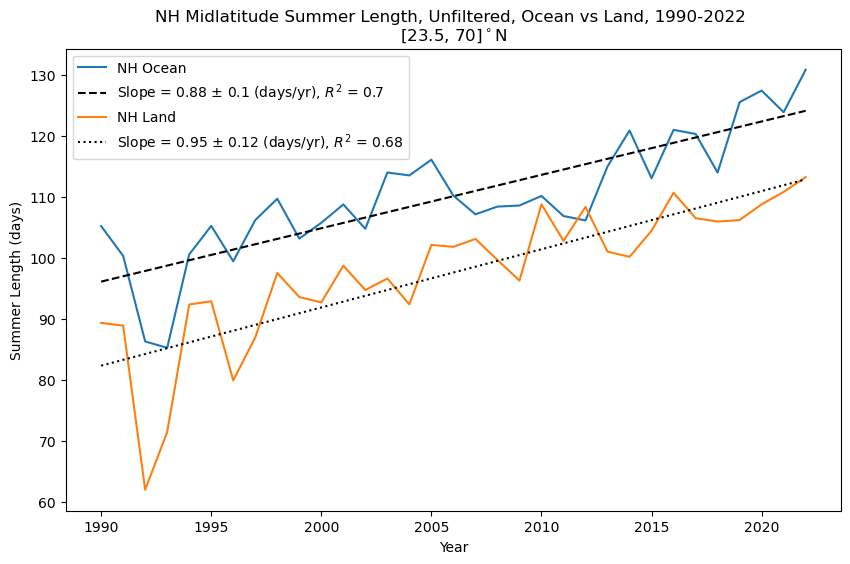

In [142]:

plt.figure(figsize=(10,6))
plt.plot(wavg_nh_ocean_sl.time.dt.year, wavg_nh_ocean_sl, label="NH Ocean")
plt.plot(x_nh, poly_o_nh(x_nh), linestyle="dashed", color='k', 
         label="Slope = "+str(slope_o_nh)+" $\pm$ "+str(slope_o_nh_sd)+" (days/yr), $R^2$ = "+str(r_squared_o_nh))
plt.plot(wavg_nh_land_sl.time.dt.year, wavg_nh_land_sl, label="NH Land")
plt.plot(x_nh, poly_nh(x_nh), linestyle="dotted", color='k', 
         label="Slope = "+str(slope_nh)+" $\pm$ "+str(slope_nh_sd)+" (days/yr), $R^2$ = "+str(r_squared_nh))
plt.xlabel("Year")
plt.ylabel("Summer Length (days)")
plt.title("NH Midlatitude Summer Length, Unfiltered, Ocean vs Land, 1990-2022 \n[23.5, 70]$^\circ$N")
plt.legend()
plt.show()

## SH Mid-latitude Ocean vs Land

<>:4: SyntaxWarning: invalid escape sequence '\p'
<>:8: SyntaxWarning: invalid escape sequence '\p'
<>:11: SyntaxWarning: invalid escape sequence '\c'
<>:4: SyntaxWarning: invalid escape sequence '\p'
<>:8: SyntaxWarning: invalid escape sequence '\p'
<>:11: SyntaxWarning: invalid escape sequence '\c'
/var/folders/x9/4cv754f12hv2bf6s__9xrzj80000gp/T/ipykernel_88424/1636055740.py:4: SyntaxWarning: invalid escape sequence '\p'
  label="Slope = "+str(slope_o_sh)+" $\pm$ "+str(slope_o_nh_sd)+" (days/yr), $R^2$ = "+str(r_squared_o_sh))
/var/folders/x9/4cv754f12hv2bf6s__9xrzj80000gp/T/ipykernel_88424/1636055740.py:8: SyntaxWarning: invalid escape sequence '\p'
  label="Slope = "+str(slope_sh)+" $\pm$ "+str(slope_nh_sd)+" (days/yr), $R^2$ = "+str(r_squared_sh))
/var/folders/x9/4cv754f12hv2bf6s__9xrzj80000gp/T/ipykernel_88424/1636055740.py:11: SyntaxWarning: invalid escape sequence '\c'
  plt.title("SH Midlatitude Summer Length, Unfiltered, Ocean vs Land, 1990-2022 \n[-70, -23]$^\circ$S")


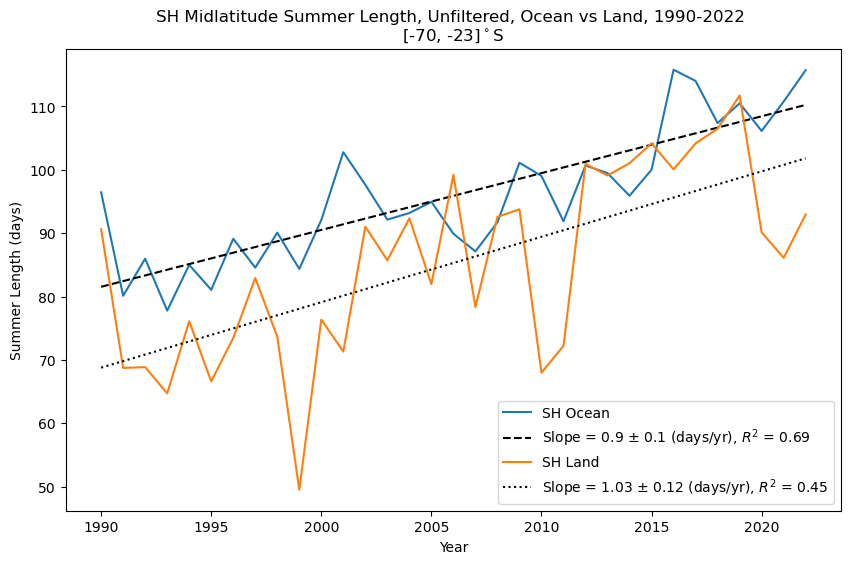

In [143]:

plt.figure(figsize=(10,6))
plt.plot(wavg_sh_ocean_sl.time.dt.year, wavg_sh_ocean_sl, label="SH Ocean")
plt.plot(x_sh, poly_o_sh(x_sh), linestyle="dashed", color='k', 
         label="Slope = "+str(slope_o_sh)+" $\pm$ "+str(slope_o_nh_sd)+" (days/yr), $R^2$ = "+str(r_squared_o_sh))

plt.plot(wavg_sh_land_sl.time.dt.year, wavg_sh_land_sl, label="SH Land")
plt.plot(x_sh, poly_sh(x_sh), linestyle="dotted", color='k',
         label="Slope = "+str(slope_sh)+" $\pm$ "+str(slope_nh_sd)+" (days/yr), $R^2$ = "+str(r_squared_sh))
plt.xlabel("Year")
plt.ylabel("Summer Length (days)")
plt.title("SH Midlatitude Summer Length, Unfiltered, Ocean vs Land, 1990-2022 \n[-70, -23]$^\circ$S")
plt.legend()
plt.show()

## Load in baseline years (1961-1990) to see longer term trend and compare to prior works like Wang et al (2021) and Lin & Wang (2022)

In [111]:
%%time

# takes ~40 sec to load

# start with one year and lsm and add a coordinate for the year
year = 1961
input_path = '../../../Data/ERA5-global/Analysis/New/'+str(year)+'_summer_stats.nc'
ds_base = xr.open_dataset(input_path)
ds_base = ds_base.merge(ds_lsm)
ds_base = ds_base.expand_dims("time").assign_coords(time=("time", [dt(year,1,1)]))

# loop thru remaining years and also add time coord
input_years = np.arange(1962,1991,1)

for year in input_years:
    input_path = '../../../Data/ERA5-global/Analysis/New/'+str(year)+'_summer_stats.nc'
    ds_i = xr.open_dataset(input_path)
    ds_i = ds_i.merge(ds_lsm)
    ds_i = ds_i.expand_dims("time").assign_coords(time=("time", [dt(year,1,1)]))
    ds_base = ds_base.merge(ds_i)

ds_base

CPU times: user 15.5 s, sys: 20.2 s, total: 35.7 s
Wall time: 41.2 s


<xarray.Dataset> Size: 2GB
Dimensions:       (lat: 721, lon: 1440, time: 30)
Coordinates:
  * lat           (lat) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * lon           (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
  * time          (time) datetime64[ns] 240B 1961-01-01 ... 1990-01-01
Data variables:
    SummerStart   (time, lat, lon) float64 249MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    SummerEnd     (time, lat, lon) float64 249MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    SummerTmax    (time, lat, lon) float64 249MB 179.0 179.0 ... 203.0 203.0
    SummerHeat    (time, lat, lon) float64 249MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    SummerLength  (time, lat, lon) float64 249MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    SummerRMSE    (time, lat, lon) float64 249MB 6.906 6.906 ... 5.745 5.745
    SummerR2      (time, lat, lon) float64 249MB 0.5105 0.5105 ... 0.6524 0.6524
    lsm           (time, lat, lon) float64 249MB 1.0 1.0 1.0 1.0 ... 0.0 0.0 0.0

### Weight by cos(lat) for global mean Summer length per baseline years

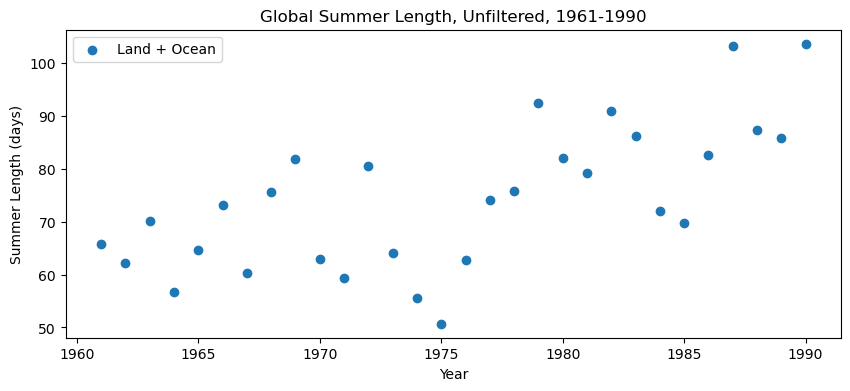

In [144]:
# find weights (this is a regular grid so we can use cos(latitude))
weights = np.cos(np.deg2rad(ds_base.lat))
weights.name = "weights"
# take the weighted spatial mean since the latitude range of the region of interest is large
wavg_glob_summ_length_base = ds_base.SummerLength.weighted(weights).mean(dim=['lat','lon'])

plt.figure(figsize=(10,4))
#plt.plot(avg_glob_summ_length.time.dt.year, avg_glob_summ_length, label="Unweighted")
plt.scatter(wavg_glob_summ_length_base.time.dt.year, wavg_glob_summ_length_base, label="Land + Ocean")
plt.xlabel("Year")
plt.ylabel("Summer Length (days)")
plt.title("Global Summer Length, Unfiltered, 1961-1990")
plt.legend()
plt.show()

### Split baseline years into Land vs Ocean

In [145]:
ds_base_land = ds_base.where(ds_base.lsm > 0.5)
ds_base_ocean = ds_base.where(ds_base.lsm <= 0.5)

<>:14: SyntaxWarning: invalid escape sequence '\c'
<>:14: SyntaxWarning: invalid escape sequence '\c'
/var/folders/x9/4cv754f12hv2bf6s__9xrzj80000gp/T/ipykernel_88424/3188712701.py:14: SyntaxWarning: invalid escape sequence '\c'
  plt.title("Global Midlatitude Summer Length, Unfiltered, Ocean vs Land, 1961-202 \n[23.5, 70]$^\circ$N and [-70, -23]$^\circ$S")


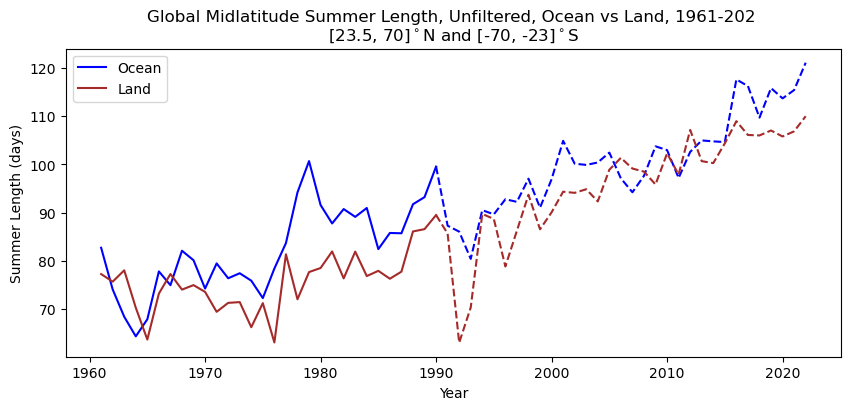

In [146]:
# take the weighted spatial mean since the latitude range of the region of interest is large
wavg_midlat_land_sl_base = ds_base_land.SummerLength.where(((ds_base_land.lat >= 23.5) & (ds_base_land.lat <= 70)) | 
                                         ((ds_base_land.lat <= -23.5) & (ds_base_land.lat >= -70))).weighted(weights).mean(dim=['lat','lon'])
wavg_midlat_ocean_sl_base = ds_base_ocean.SummerLength.where(((ds_base_ocean.lat >= 23.5) & (ds_base_ocean.lat <= 70)) |
                                           ((ds_base_ocean.lat <= -23.5) & (ds_base_ocean.lat >= -70))).weighted(weights).mean(dim=['lat','lon'])

plt.figure(figsize=(10,4))
plt.plot(wavg_midlat_ocean_sl_base.time.dt.year, wavg_midlat_ocean_sl_base, label="Ocean", color="blue")
plt.plot(wavg_midlat_land_sl_base.time.dt.year, wavg_midlat_land_sl_base, label="Land", color="brown")
plt.plot(wavg_midlat_ocean_sl.time.dt.year, wavg_midlat_ocean_sl, label="", linestyle="--", color="blue")
plt.plot(wavg_midlat_land_sl.time.dt.year, wavg_midlat_land_sl, label="", linestyle="--", color="brown")
plt.xlabel("Year")
plt.ylabel("Summer Length (days)")
plt.title("Global Midlatitude Summer Length, Unfiltered, Ocean vs Land, 1961-202 \n[23.5, 70]$^\circ$N and [-70, -23]$^\circ$S")
plt.legend()
plt.show()

In [147]:
ds_full_land = ds_base_land.merge(ds_land)
ds_full_land

<xarray.Dataset> Size: 4GB
Dimensions:       (lat: 721, lon: 1440, time: 62)
Coordinates:
  * lat           (lat) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * lon           (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
  * time          (time) datetime64[ns] 496B 1961-01-01 ... 2022-01-01
Data variables:
    SummerStart   (time, lat, lon) float64 515MB 0.0 0.0 0.0 0.0 ... nan nan nan
    SummerEnd     (time, lat, lon) float64 515MB 0.0 0.0 0.0 0.0 ... nan nan nan
    SummerTmax    (time, lat, lon) float64 515MB 179.0 179.0 179.0 ... nan nan
    SummerHeat    (time, lat, lon) float64 515MB 0.0 0.0 0.0 0.0 ... nan nan nan
    SummerLength  (time, lat, lon) float64 515MB 0.0 0.0 0.0 0.0 ... nan nan nan
    SummerRMSE    (time, lat, lon) float64 515MB 6.906 6.906 6.906 ... nan nan
    SummerR2      (time, lat, lon) float64 515MB 0.5105 0.5105 ... nan nan
    lsm           (time, lat, lon) float64 515MB 1.0 1.0 1.0 1.0 ... nan nan nan

In [148]:
ds_full_ocean = ds_base_ocean.merge(ds_ocean)
ds_full_ocean

<xarray.Dataset> Size: 4GB
Dimensions:       (lat: 721, lon: 1440, time: 62)
Coordinates:
  * lat           (lat) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * lon           (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
  * time          (time) datetime64[ns] 496B 1961-01-01 ... 2022-01-01
Data variables:
    SummerStart   (time, lat, lon) float64 515MB nan nan nan ... 212.0 212.0
    SummerEnd     (time, lat, lon) float64 515MB nan nan nan ... 242.0 242.0
    SummerTmax    (time, lat, lon) float64 515MB nan nan nan ... 213.0 213.0
    SummerHeat    (time, lat, lon) float64 515MB nan nan ... 8.191e+03 8.191e+03
    SummerLength  (time, lat, lon) float64 515MB nan nan nan ... 31.0 31.0 31.0
    SummerRMSE    (time, lat, lon) float64 515MB nan nan nan ... 4.992 4.992
    SummerR2      (time, lat, lon) float64 515MB nan nan nan ... 0.7734 0.7734
    lsm           (time, lat, lon) float64 515MB nan nan nan nan ... 0.0 0.0 0.0

In [129]:
# write that out for later use
output_path = '../../../Data/ERA5-global/Analysis/New/1961-2022_LAND_summer_stats.nc'
ds_full_land.to_netcdf(output_path)

output_path2 = '../../../Data/ERA5-global/Analysis/New/1961-2022_OCEAN_summer_stats.nc'
ds_full_ocean.to_netcdf(output_path2)



### NH and SH Mid-latitude Summer Length for LAND over period (1961-2012) to compare to prior works

<>:56: SyntaxWarning: invalid escape sequence '\p'
<>:60: SyntaxWarning: invalid escape sequence '\p'
<>:64: SyntaxWarning: invalid escape sequence '\c'
<>:56: SyntaxWarning: invalid escape sequence '\p'
<>:60: SyntaxWarning: invalid escape sequence '\p'
<>:64: SyntaxWarning: invalid escape sequence '\c'
/var/folders/x9/4cv754f12hv2bf6s__9xrzj80000gp/T/ipykernel_88424/2064551555.py:56: SyntaxWarning: invalid escape sequence '\p'
  label="Slope = "+str(slope_nh)+" $\pm$ "+str(slope_nh_sd)+" (days/yr), $R^2$ = "+str(r_squared_nh))
/var/folders/x9/4cv754f12hv2bf6s__9xrzj80000gp/T/ipykernel_88424/2064551555.py:60: SyntaxWarning: invalid escape sequence '\p'
  label="Slope = "+str(slope_sh)+" $\pm$ "+str(slope_nh_sd)+" (days/yr), $R^2$ = "+str(r_squared_sh))
/var/folders/x9/4cv754f12hv2bf6s__9xrzj80000gp/T/ipykernel_88424/2064551555.py:64: SyntaxWarning: invalid escape sequence '\c'
  plt.title("Midlatitude Land Summer Length, Unfiltered, NH vs SH, 1961-2012 \n[23.5, 70]$^\circ$N or [-70, -

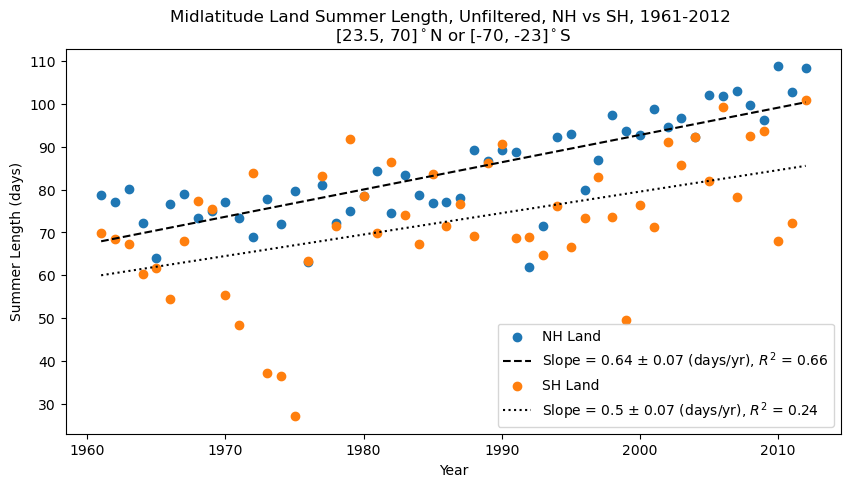

In [149]:
# take the weighted spatial mean since the latitude range of the region of interest is large

# NH
wavg_nh_land_sl = ds_full_land.SummerLength.where(((ds_full_land.lat >= 23.5) & (ds_full_land.lat <= 70))).weighted(weights).mean(dim=['lat','lon'])

# filter to 1961-2012
wavg_nh_land_sl = wavg_nh_land_sl.sel(time=slice('1961','2012'))

# x & y
x_nh = wavg_nh_land_sl.time.dt.year.values
y_nh = wavg_nh_land_sl.values

# linear fit
# error on slope via https://stackoverflow.com/questions/27634270/how-to-find-error-on-slope-and-intercept-using-numpy-polyfit
# error is stddev of 
coefs_nh, V = np.polyfit(x_nh, y_nh, 1, cov=True)
poly_nh = np.poly1d(coefs_nh)
slope_nh = np.round(coefs_nh[0],2)
slope_nh_sd = np.round(np.sqrt(V[0][0]),2)


# add in R^2 and RMSE
ymean = np.mean(y_nh)
ss_total = np.sum((y_nh - ymean)**2)
ss_res = np.sum((y_nh - poly_nh(x_nh))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_nh = np.round(1 - (ss_res / ss_total),2)

# SH
wavg_sh_land_sl = ds_full_land.SummerLength.where(((ds_full_land.lat <= -23.5) & (ds_full_land.lat >= -70))).weighted(weights).mean(dim=['lat','lon'])

# filter to 1961-2012
wavg_sh_land_sl = wavg_sh_land_sl.sel(time=slice('1961','2012'))

# x & y
x_sh = wavg_sh_land_sl.time.dt.year.values
y_sh = wavg_sh_land_sl.values

# linear fit
coefs_sh, V = np.polyfit(x_sh, y_sh, 1, cov=True)
poly_sh = np.poly1d(coefs_sh)
slope_sh = np.round(coefs_sh[0],2)
slope_sh_sd = np.round(np.sqrt(V[0][0]),2)

# add in R^2 and RMSE
ymean = np.mean(y_sh)
ss_total = np.sum((y_sh - ymean)**2)
ss_res = np.sum((y_sh - poly_sh(x_sh))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_sh = np.round(1 - (ss_res / ss_total),2)


plt.figure(figsize=(10,5))
plt.scatter(wavg_nh_land_sl.time.dt.year, wavg_nh_land_sl, label="NH Land")
plt.plot(x_nh, poly_nh(x_nh), linestyle="dashed", color='k', 
         label="Slope = "+str(slope_nh)+" $\pm$ "+str(slope_nh_sd)+" (days/yr), $R^2$ = "+str(r_squared_nh))

plt.scatter(wavg_sh_land_sl.time.dt.year, wavg_sh_land_sl, label="SH Land")
plt.plot(x_sh, poly_sh(x_sh), linestyle="dotted", color='k',
         label="Slope = "+str(slope_sh)+" $\pm$ "+str(slope_nh_sd)+" (days/yr), $R^2$ = "+str(r_squared_sh))

plt.xlabel("Year")
plt.ylabel("Summer Length (days)")
plt.title("Midlatitude Land Summer Length, Unfiltered, NH vs SH, 1961-2012 \n[23.5, 70]$^\circ$N or [-70, -23]$^\circ$S")
plt.legend()
plt.show()

### Hmm, might be influenced by some of our poor $R^2$ cells so as a quick test of sensitivity, only use cells with $R^{2} \geq 0.5$

<>:60: SyntaxWarning: invalid escape sequence '\p'
<>:64: SyntaxWarning: invalid escape sequence '\p'
<>:68: SyntaxWarning: invalid escape sequence '\g'
<>:60: SyntaxWarning: invalid escape sequence '\p'
<>:64: SyntaxWarning: invalid escape sequence '\p'
<>:68: SyntaxWarning: invalid escape sequence '\g'
/var/folders/x9/4cv754f12hv2bf6s__9xrzj80000gp/T/ipykernel_88424/4231613907.py:60: SyntaxWarning: invalid escape sequence '\p'
  label="Slope = "+str(slope_nh)+" $\pm$ "+str(slope_nh_sd)+" (days/yr), $R^2$ = "+str(r_squared_nh))
/var/folders/x9/4cv754f12hv2bf6s__9xrzj80000gp/T/ipykernel_88424/4231613907.py:64: SyntaxWarning: invalid escape sequence '\p'
  label="Slope = "+str(slope_sh)+" $\pm$ "+str(slope_nh_sd)+" (days/yr), $R^2$ = "+str(r_squared_sh))
/var/folders/x9/4cv754f12hv2bf6s__9xrzj80000gp/T/ipykernel_88424/4231613907.py:68: SyntaxWarning: invalid escape sequence '\g'
  plt.title("Midlatitude Land Summer Length, $R^{2} \geq 0.5$, NH vs SH, 1961-2012 \n[23.5, 70]$^\circ$N or [

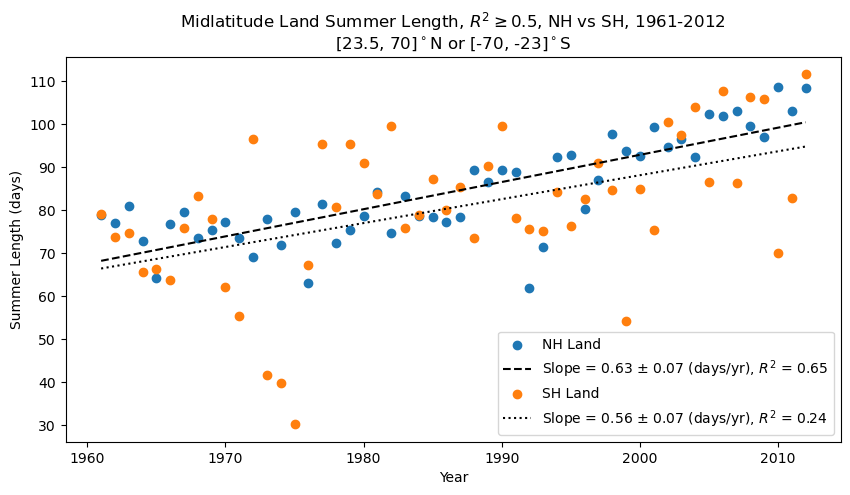

In [150]:
# filter land data to only cells with R^2 > 0.3
ds_full_land_filt = ds_full_land.where(ds_full_land.SummerR2 >= 0.5)


# take the weighted spatial mean since the latitude range of the region of interest is large

# NH
wavg_nh_land_sl = ds_full_land_filt.SummerLength.where(((ds_full_land_filt.lat >= 23.5) & (ds_full_land_filt.lat <= 70))).weighted(weights).mean(dim=['lat','lon'])

# filter to 1961-2014 - same as Lin & Wang 2022
wavg_nh_land_sl = wavg_nh_land_sl.sel(time=slice('1961','2012'))

# x & y
x_nh = wavg_nh_land_sl.time.dt.year.values
y_nh = wavg_nh_land_sl.values

# linear fit
# error on slope via https://stackoverflow.com/questions/27634270/how-to-find-error-on-slope-and-intercept-using-numpy-polyfit
# error is stddev of 
coefs_nh, V = np.polyfit(x_nh, y_nh, 1, cov=True)
poly_nh = np.poly1d(coefs_nh)
slope_nh = np.round(coefs_nh[0],2)
slope_nh_sd = np.round(np.sqrt(V[0][0]),2)


# add in R^2 and RMSE
ymean = np.mean(y_nh)
ss_total = np.sum((y_nh - ymean)**2)
ss_res = np.sum((y_nh - poly_nh(x_nh))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_nh = np.round(1 - (ss_res / ss_total),2)

# SH
wavg_sh_land_sl = ds_full_land_filt.SummerLength.where(((ds_full_land_filt.lat <= -23.5) & (ds_full_land_filt.lat >= -70))).weighted(weights).mean(dim=['lat','lon'])

# filter to 1961-2012
wavg_sh_land_sl = wavg_sh_land_sl.sel(time=slice('1961','2012'))

# x & y
x_sh = wavg_sh_land_sl.time.dt.year.values
y_sh = wavg_sh_land_sl.values

# linear fit
coefs_sh, V = np.polyfit(x_sh, y_sh, 1, cov=True)
poly_sh = np.poly1d(coefs_sh)
slope_sh = np.round(coefs_sh[0],2)
slope_sh_sd = np.round(np.sqrt(V[0][0]),2)

# add in R^2 and RMSE
ymean = np.mean(y_sh)
ss_total = np.sum((y_sh - ymean)**2)
ss_res = np.sum((y_sh - poly_sh(x_sh))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_sh = np.round(1 - (ss_res / ss_total),2)


plt.figure(figsize=(10,5))
plt.scatter(wavg_nh_land_sl.time.dt.year, wavg_nh_land_sl, label="NH Land")
plt.plot(x_nh, poly_nh(x_nh), linestyle="dashed", color='k', 
         label="Slope = "+str(slope_nh)+" $\pm$ "+str(slope_nh_sd)+" (days/yr), $R^2$ = "+str(r_squared_nh))

plt.scatter(wavg_sh_land_sl.time.dt.year, wavg_sh_land_sl, label="SH Land")
plt.plot(x_sh, poly_sh(x_sh), linestyle="dotted", color='k',
         label="Slope = "+str(slope_sh)+" $\pm$ "+str(slope_nh_sd)+" (days/yr), $R^2$ = "+str(r_squared_sh))

plt.xlabel("Year")
plt.ylabel("Summer Length (days)")
plt.title("Midlatitude Land Summer Length, $R^{2} \geq 0.5$, NH vs SH, 1961-2012 \n[23.5, 70]$^\circ$N or [-70, -23]$^\circ$S")
plt.legend()
plt.show()

### Essentially the same results with and without the $R^2$ filter which is a promising sign

### <br> Try the above, but for OCEAN

<>:56: SyntaxWarning: invalid escape sequence '\p'
<>:60: SyntaxWarning: invalid escape sequence '\p'
<>:64: SyntaxWarning: invalid escape sequence '\c'
<>:56: SyntaxWarning: invalid escape sequence '\p'
<>:60: SyntaxWarning: invalid escape sequence '\p'
<>:64: SyntaxWarning: invalid escape sequence '\c'
/var/folders/x9/4cv754f12hv2bf6s__9xrzj80000gp/T/ipykernel_88424/759816142.py:56: SyntaxWarning: invalid escape sequence '\p'
  label="Slope = "+str(slope_nh)+" $\pm$ "+str(slope_nh_sd)+" (days/yr), $R^2$ = "+str(r_squared_nh))
/var/folders/x9/4cv754f12hv2bf6s__9xrzj80000gp/T/ipykernel_88424/759816142.py:60: SyntaxWarning: invalid escape sequence '\p'
  label="Slope = "+str(slope_sh)+" $\pm$ "+str(slope_nh_sd)+" (days/yr), $R^2$ = "+str(r_squared_sh))
/var/folders/x9/4cv754f12hv2bf6s__9xrzj80000gp/T/ipykernel_88424/759816142.py:64: SyntaxWarning: invalid escape sequence '\c'
  plt.title("Midlatitude Ocean Summer Length, Unfiltered, NH vs SH, 1961-2012 \n[23.5, 70]$^\circ$N or [-70, -23

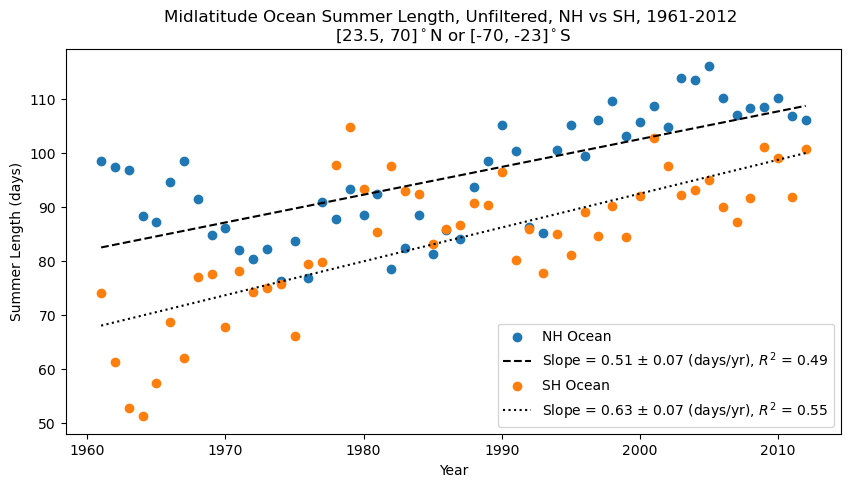

In [151]:
# take the weighted spatial mean since the latitude range of the region of interest is large

# NH
wavg_nh_ocean_sl = ds_full_ocean.SummerLength.where(((ds_full_ocean.lat >= 23.5) & (ds_full_ocean.lat <= 70))).weighted(weights).mean(dim=['lat','lon'])

# filter to 1961-2012
wavg_nh_ocean_sl = wavg_nh_ocean_sl.sel(time=slice('1961','2012'))

# x & y
x_nh = wavg_nh_ocean_sl.time.dt.year.values
y_nh = wavg_nh_ocean_sl.values

# linear fit
# error on slope via https://stackoverflow.com/questions/27634270/how-to-find-error-on-slope-and-intercept-using-numpy-polyfit
# error is stddev of 
coefs_nh, V = np.polyfit(x_nh, y_nh, 1, cov=True)
poly_nh = np.poly1d(coefs_nh)
slope_nh = np.round(coefs_nh[0],2)
slope_nh_sd = np.round(np.sqrt(V[0][0]),2)


# add in R^2 and RMSE
ymean = np.mean(y_nh)
ss_total = np.sum((y_nh - ymean)**2)
ss_res = np.sum((y_nh - poly_nh(x_nh))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_nh = np.round(1 - (ss_res / ss_total),2)

# SH
wavg_sh_ocean_sl = ds_full_ocean.SummerLength.where(((ds_full_ocean.lat <= -23.5) & (ds_full_ocean.lat >= -70))).weighted(weights).mean(dim=['lat','lon'])

# filter to 1961-2012
wavg_sh_ocean_sl = wavg_sh_ocean_sl.sel(time=slice('1961','2012'))

# x & y
x_sh = wavg_sh_ocean_sl.time.dt.year.values
y_sh = wavg_sh_ocean_sl.values

# linear fit
coefs_sh, V = np.polyfit(x_sh, y_sh, 1, cov=True)
poly_sh = np.poly1d(coefs_sh)
slope_sh = np.round(coefs_sh[0],2)
slope_sh_sd = np.round(np.sqrt(V[0][0]),2)

# add in R^2 and RMSE
ymean = np.mean(y_sh)
ss_total = np.sum((y_sh - ymean)**2)
ss_res = np.sum((y_sh - poly_sh(x_sh))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_sh = np.round(1 - (ss_res / ss_total),2)


plt.figure(figsize=(10,5))
plt.scatter(wavg_nh_ocean_sl.time.dt.year, wavg_nh_ocean_sl, label="NH Ocean")
plt.plot(x_nh, poly_nh(x_nh), linestyle="dashed", color='k', 
         label="Slope = "+str(slope_nh)+" $\pm$ "+str(slope_nh_sd)+" (days/yr), $R^2$ = "+str(r_squared_nh))

plt.scatter(wavg_sh_ocean_sl.time.dt.year, wavg_sh_ocean_sl, label="SH Ocean")
plt.plot(x_sh, poly_sh(x_sh), linestyle="dotted", color='k',
         label="Slope = "+str(slope_sh)+" $\pm$ "+str(slope_nh_sd)+" (days/yr), $R^2$ = "+str(r_squared_sh))

plt.xlabel("Year")
plt.ylabel("Summer Length (days)")
plt.title("Midlatitude Ocean Summer Length, Unfiltered, NH vs SH, 1961-2012 \n[23.5, 70]$^\circ$N or [-70, -23]$^\circ$S")
plt.legend()
plt.show()

### Also the sensitivity test by filtering to grid cells with $R^2 \geq 0.5$

<>:60: SyntaxWarning: invalid escape sequence '\p'
<>:64: SyntaxWarning: invalid escape sequence '\p'
<>:68: SyntaxWarning: invalid escape sequence '\g'
<>:60: SyntaxWarning: invalid escape sequence '\p'
<>:64: SyntaxWarning: invalid escape sequence '\p'
<>:68: SyntaxWarning: invalid escape sequence '\g'
/var/folders/x9/4cv754f12hv2bf6s__9xrzj80000gp/T/ipykernel_88424/2543859578.py:60: SyntaxWarning: invalid escape sequence '\p'
  label="Slope = "+str(slope_nh)+" $\pm$ "+str(slope_nh_sd)+" (days/yr), $R^2$ = "+str(r_squared_nh))
/var/folders/x9/4cv754f12hv2bf6s__9xrzj80000gp/T/ipykernel_88424/2543859578.py:64: SyntaxWarning: invalid escape sequence '\p'
  label="Slope = "+str(slope_sh)+" $\pm$ "+str(slope_nh_sd)+" (days/yr), $R^2$ = "+str(r_squared_sh))
/var/folders/x9/4cv754f12hv2bf6s__9xrzj80000gp/T/ipykernel_88424/2543859578.py:68: SyntaxWarning: invalid escape sequence '\g'
  plt.title("Midlatitude Ocean Summer Length, $R^{2} \geq 0.5$, NH vs SH, 1961-2012 \n[23.5, 70]$^\circ$N or 

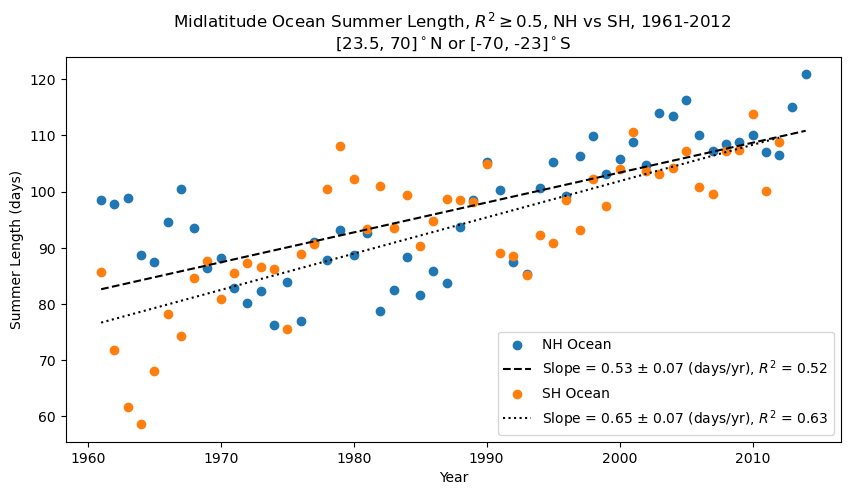

In [152]:
# filter ocean data to only cells with R^2 > 0.3
ds_full_ocean_filt = ds_full_ocean.where(ds_full_ocean.SummerR2 >= 0.5)


# take the weighted spatial mean since the latitude range of the region of interest is large

# NH
wavg_nh_ocean_sl = ds_full_ocean_filt.SummerLength.where(((ds_full_ocean_filt.lat >= 23.5) & (ds_full_ocean_filt.lat <= 70))).weighted(weights).mean(dim=['lat','lon'])

# filter to 1961-2014 - same as Lin & Wang 2022
wavg_nh_ocean_sl = wavg_nh_ocean_sl.sel(time=slice('1961','2014'))

# x & y
x_nh = wavg_nh_ocean_sl.time.dt.year.values
y_nh = wavg_nh_ocean_sl.values

# linear fit
# error on slope via https://stackoverflow.com/questions/27634270/how-to-find-error-on-slope-and-intercept-using-numpy-polyfit
# error is stddev of 
coefs_nh, V = np.polyfit(x_nh, y_nh, 1, cov=True)
poly_nh = np.poly1d(coefs_nh)
slope_nh = np.round(coefs_nh[0],2)
slope_nh_sd = np.round(np.sqrt(V[0][0]),2)


# add in R^2 and RMSE
ymean = np.mean(y_nh)
ss_total = np.sum((y_nh - ymean)**2)
ss_res = np.sum((y_nh - poly_nh(x_nh))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_nh = np.round(1 - (ss_res / ss_total),2)

# SH
wavg_sh_ocean_sl = ds_full_ocean_filt.SummerLength.where(((ds_full_ocean_filt.lat <= -23.5) & (ds_full_ocean_filt.lat >= -70))).weighted(weights).mean(dim=['lat','lon'])

# filter to 1961-2012
wavg_sh_ocean_sl = wavg_sh_ocean_sl.sel(time=slice('1961','2012'))

# x & y
x_sh = wavg_sh_ocean_sl.time.dt.year.values
y_sh = wavg_sh_ocean_sl.values

# linear fit
coefs_sh, V = np.polyfit(x_sh, y_sh, 1, cov=True)
poly_sh = np.poly1d(coefs_sh)
slope_sh = np.round(coefs_sh[0],2)
slope_sh_sd = np.round(np.sqrt(V[0][0]),2)

# add in R^2 and RMSE
ymean = np.mean(y_sh)
ss_total = np.sum((y_sh - ymean)**2)
ss_res = np.sum((y_sh - poly_sh(x_sh))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_sh = np.round(1 - (ss_res / ss_total),2)


plt.figure(figsize=(10,5))
plt.scatter(wavg_nh_ocean_sl.time.dt.year, wavg_nh_ocean_sl, label="NH Ocean")
plt.plot(x_nh, poly_nh(x_nh), linestyle="dashed", color='k', 
         label="Slope = "+str(slope_nh)+" $\pm$ "+str(slope_nh_sd)+" (days/yr), $R^2$ = "+str(r_squared_nh))

plt.scatter(wavg_sh_ocean_sl.time.dt.year, wavg_sh_ocean_sl, label="SH Ocean")
plt.plot(x_sh, poly_sh(x_sh), linestyle="dotted", color='k',
         label="Slope = "+str(slope_sh)+" $\pm$ "+str(slope_nh_sd)+" (days/yr), $R^2$ = "+str(r_squared_sh))

plt.xlabel("Year")
plt.ylabel("Summer Length (days)")
plt.title("Midlatitude Ocean Summer Length, $R^{2} \geq 0.5$, NH vs SH, 1961-2012 \n[23.5, 70]$^\circ$N or [-70, -23]$^\circ$S")
plt.legend()
plt.show()